In [8]:
import pandas as pd
import nltk

nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
!pip install deep_translator
from deep_translator import GoogleTranslator

In [10]:
data = pd.read_csv('Clean_tweet.csv')
data.head()

,Unnamed: 0,Tweet
0,0,yuk bikin tahun jadi milik dalam wujud impi si...
1,1,mulai tahun cerdas simak tips resolusi uang ti...
2,2,kirim dipan meja rias jakartauntuk mesan hubun...
3,3,sama wujud visi rektor its bawa kampus tuju ma...
4,4,terimakasih belum buat tahun aku banyak ajar l...


In [11]:
#Terjemahkan tiap kata agar bisa dianalisis NLTK
def trans(words):
  translated = GoogleTranslator(source='id', target='en').translate(words)
  return translated

data['Tweet_trans'] = data['Tweet'].apply(trans)
data = data.iloc[: , 1:]
data.head()

,Tweet,Tweet_trans
0,yuk bikin tahun jadi milik dalam wujud impi si...,let's make the year ours in the form of dreams...
1,mulai tahun cerdas simak tips resolusi uang ti...,"start the year smart, check out money resoluti..."
2,kirim dipan meja rias jakartauntuk mesan hubun...,"send a dressing table bed in Jakarta to order,..."
3,sama wujud visi rektor its bawa kampus tuju ma...,the same as the vision of the rector of its to...
4,terimakasih belum buat tahun aku banyak ajar l...,Thank you for not making this year I taught a ...


In [12]:
Analyze = SentimentIntensityAnalyzer()

#Menghitung polarity score tiap Tweet
def polarity_scores(words):
  score = Analyze.polarity_scores(words)
  return score

data['polarity_scores'] = data['Tweet_trans'].apply(polarity_scores)

#Menampilkan compound score tiap Tweet untuk dijadikan klasifikasi positif-negatif
def compound_score(words):
  score = words['compound']
  return score

data['compound_score'] = data['polarity_scores'].apply(compound_score)

data.head()

,Tweet,Tweet_trans,polarity_scores,compound_score
0,yuk bikin tahun jadi milik dalam wujud impi si...,let's make the year ours in the form of dreams...,"{'neg': 0.0, 'neu': 0.644, 'pos': 0.356, 'comp...",0.8176
1,mulai tahun cerdas simak tips resolusi uang ti...,"start the year smart, check out money resoluti...","{'neg': 0.0, 'neu': 0.704, 'pos': 0.296, 'comp...",0.7096
2,kirim dipan meja rias jakartauntuk mesan hubun...,"send a dressing table bed in Jakarta to order,...","{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000
3,sama wujud visi rektor its bawa kampus tuju ma...,the same as the vision of the rector of its to...,"{'neg': 0.0, 'neu': 0.839, 'pos': 0.161, 'comp...",0.5574
4,terimakasih belum buat tahun aku banyak ajar l...,Thank you for not making this year I taught a ...,"{'neg': 0.101, 'neu': 0.548, 'pos': 0.351, 'co...",0.8860


##Visualisasi Data

,Tweet,Tweet_trans,polarity_scores,compound_score,Sentimen
0,yuk bikin tahun jadi milik dalam wujud impi si...,let's make the year ours in the form of dreams...,"{'neg': 0.0, 'neu': 0.644, 'pos': 0.356, 'comp...",0.8176,Positif
1,mulai tahun cerdas simak tips resolusi uang ti...,"start the year smart, check out money resoluti...","{'neg': 0.0, 'neu': 0.704, 'pos': 0.296, 'comp...",0.7096,Positif
2,kirim dipan meja rias jakartauntuk mesan hubun...,"send a dressing table bed in Jakarta to order,...","{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,Netral
3,sama wujud visi rektor its bawa kampus tuju ma...,the same as the vision of the rector of its to...,"{'neg': 0.0, 'neu': 0.839, 'pos': 0.161, 'comp...",0.5574,Positif
4,terimakasih belum buat tahun aku banyak ajar l...,Thank you for not making this year I taught a ...,"{'neg': 0.101, 'neu': 0.548, 'pos': 0.351, 'co...",0.8860,Positif


,count
Sentimen,
Positif,83
Netral,11
Negatif,6


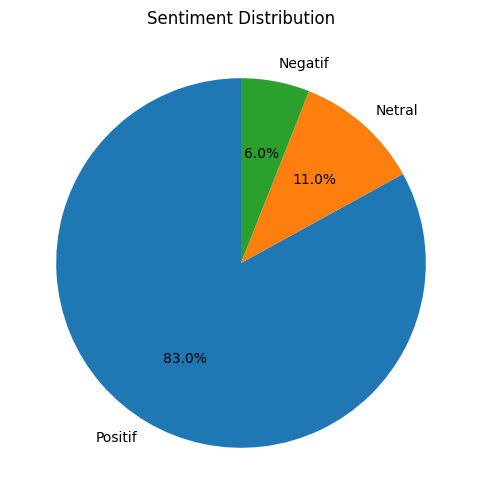

In [13]:
#Membuat klasifikasi sentimen

data['Sentimen']='Netral'
data.loc[data['compound_score'] > 0, 'Sentimen'] = 'Positif'
data.loc[data['compound_score'] < 0, 'Sentimen'] = 'Negatif'
display(data.head())

sentiment_counts = data['Sentimen'].value_counts()
display(sentiment_counts)

# Membuat pie chart jumlah sentimen
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Sentiment Distribution')
plt.show()

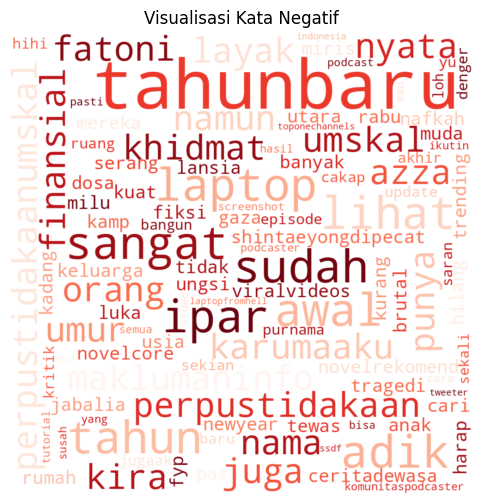

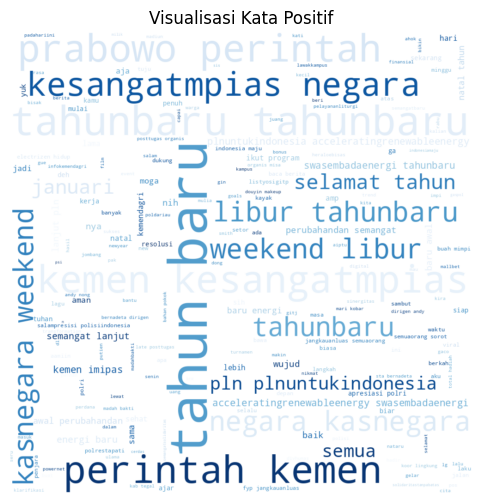

In [14]:
#Membuat Wordcloud
tweet_positif = data[data['compound_score'] > 0]
tweet_negatif = data[data['compound_score'] < 0]
tweet_netral = data[data['compound_score'] == 0]

all_text_s0 = ' '.join(word for word in tweet_negatif['Tweet'])
wordcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s0)
plt.figure(figsize=(9,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Visualisasi Kata Negatif')
plt.margins(x=0, y=0)
plt.show()

print('')

all_text_s0 = ' '.join(word for word in tweet_positif['Tweet'])
wordcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s0)
plt.figure(figsize=(9,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Visualisasi Kata Positif')
plt.margins(x=0, y=0)
plt.show()